# Aircraft Engine Predictive Maintenance

## Notebook 7: LSTM Time Series Prediction

### Objectives

- Load processed dataset
- Create sequences
- Build LSTM model
- Train model
- Evaluate performance
- Save trained model

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
data = pd.read_csv("../dataset/processed_train.csv")

print(data.shape)

data.head()

(20631, 20)


,engine_id,cycle,setting1,setting2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,0.0,0.00000,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191.0
1,0.0,0.00277,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190.0
2,0.0,0.00554,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189.0
3,0.0,0.00831,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188.0
4,0.0,0.01108,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187.0


In [4]:
X = data.drop("RUL", axis=1).values

y = data["RUL"].values

In [5]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [6]:
sequence_length = 30

X_seq = []
y_seq = []

for i in range(len(X) - sequence_length):
    X_seq.append(X[i:i + sequence_length])
    y_seq.append(y[i + sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)
print(y_seq.shape)

(20601, 30, 19)
(20601,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

In [8]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

d:\Aircraft_Engine_Predictive_Maintenance\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,465 (134.63 KB)

 Trainable params: 34,465 (134.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - loss: 11951.9980 - mae: 87.5010 - val_loss: 7998.9326 - val_mae: 69.6083
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - loss: 5946.1221 - mae: 61.1589 - val_loss: 4904.1875 - val_mae: 57.2783
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 4856.3408 - mae: 57.1418 - val_loss: 4796.7637 - val_mae: 57.2420
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 4872.5283 - mae: 57.3883 - val_loss: 4796.8643 - val_mae: 57.2709
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - loss: 4833.1221 - mae: 57.2195 - val_loss: 4797.3779 - val_mae: 57.2991
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 4839.7407 - mae: 57.2419 - val_loss: 4796.7588 - val_mae: 57.2565
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 4855.0854 - mae: 57.4071 - val_loss: 4797.0874 - val_mae: 57.2180
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - loss: 4822.0146 - mae: 57.2065 - val_loss: 479

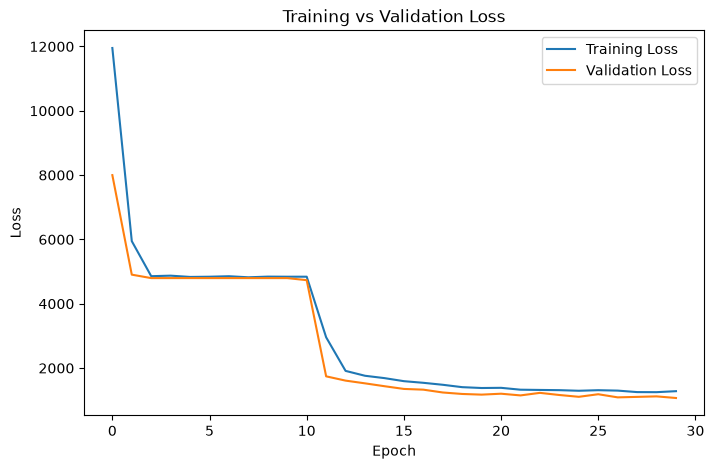

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [12]:
prediction = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step


In [13]:
mae = mean_absolute_error(y_test, prediction)

rmse = np.sqrt(mean_squared_error(y_test, prediction))

r2 = r2_score(y_test, prediction)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 21.785486585102856
RMSE : 32.60692965195282
R² : 0.7719240756193932


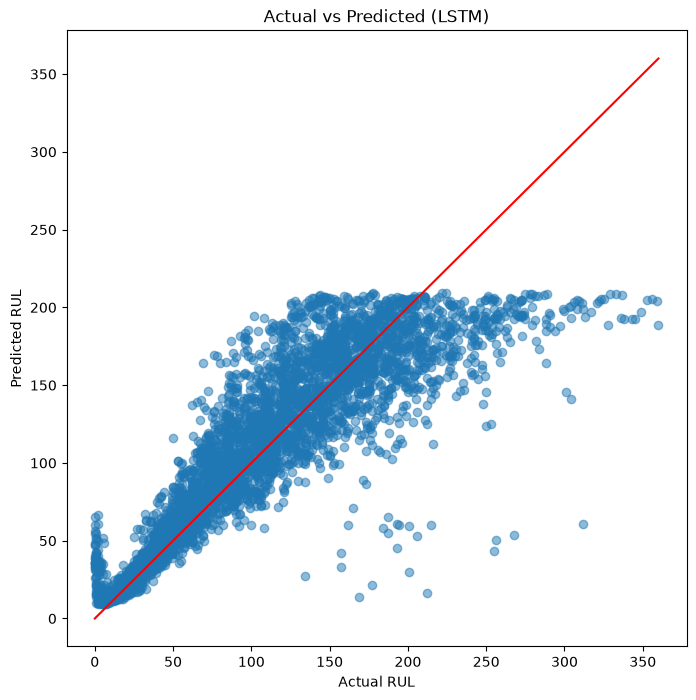

In [14]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    prediction,
    alpha=0.5
)

plt.plot(
    [0, max(y_test)],
    [0, max(y_test)],
    color="red"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted (LSTM)")

plt.show()

In [15]:
model.save("../models/lstm_model.keras")

print("LSTM Model Saved Successfully")

LSTM Model Saved Successfully


In [16]:
from tensorflow.keras.models import load_model

loaded_model = load_model("../models/lstm_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully
